---
## Particle Simulation Evolution Model

Objective:
- Keep the model modular so parameters and update rules can be optimised later.

Success criteria:
- Model particle motion on the observed `x-z` slice.
- Model particle appearance and disappearance caused by out-of-plane motion through the pixel-thickness visibility band.
- Keep the particle cloud randomly distributed in space instead of artificially clustering near one interface.


## Notebook Structure

### Section I: Core Particle Evolution Interfaces
1. Module 0: Notebook setup, particle parameters, and unified debug parameters
2. Module 1: Assumptions and latent particle state
3. Module 2: Core particle dynamics
4. Module 3: Initial particle cloud
5. Module 4: Rollout and public interfaces

### Section II: Diagnostics, Visualisation, and Export-Style Outputs
6. Module 5: Particle outputs
7. Module 6: Default run and diagnostics
8. Module 7: GIF visualisation

# Section I: Core Particle Evolution Interfaces

This section collects the full particle-evolution pipeline that another team member would need in order to call the reduced-order particle model from outside the notebook.

The section includes:
- the notebook setup and parameter block,
- the latent particle state definition,
- the reduced-order particle dynamics,
- the initial cloud generator,
- and the rollout interfaces that return the particle history and visible-point sequence.

## Module 0: Notebook Setup, Particle Parameters, and Unified Debug Parameters

The opening code cells initialise the particle-evolution notebook and define the configuration used by the reduced-order surrogate.

This setup stage contains:
- the reproducibility controls and notebook imports,
- the particle-model parameter block `SimConfig`,
- and one unified debug/interface parameter block used by the later demonstration and GIF cells.

In [1]:
# Module 0A: imports and reproducibility
from __future__ import annotations

import io
from dataclasses import dataclass

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

SEED = 10
ATWOOD_REF = 0.0695
rng = np.random.default_rng(SEED)

In [2]:
# Module 0B: parameter block for the particle-evolution notebook
@dataclass
class SimConfig:
    """Configuration for the particle-based reduced-order surrogate."""
    # time discretisation
    dt: float = 0.02
    accel_1_duration: float = 0.88
    decel_duration: float = 1.44
    accel_2_duration: float = 0.88

    # particle count
    N: int = 80000

    # physical domain 
    Lx: float = 0.2
    Ly: float = 0.2
    zmin: float = -0.2
    zmax: float = 0.2

    # Task / CAMPI-inspired mode settings
    atwood: float = 0.0695
    mode_number: int = 6
    initial_amplitude: float = 2.0e-4
    max_amplitude: float = 8.0e-3
    gamma_ref: float = 2.4
    unstable_accel: float = 20.0
    stable_accel: float = -30.0

    # in-plane random motion and weak background drift
    particle_noise_sigma: float = 1.6e-3
    flow_weight: float = 0.10

    # out-of-plane random motion across the full depth
    y_noise_sigma: float = 0.004

    # visibility gating: constant pixel thickness in y
    enable_visibility_gate: bool = True
    slice_center_y: float = 0.0
    pixel_thickness: float = 1.2e-3

    gif_stride: int = 4
    gif_frame_duration: float = 0.12

    seed: int = 10

    @property
    def total_time(self):
        return self.accel_1_duration + self.decel_duration + self.accel_2_duration

    @property
    def T(self):
        return int(np.ceil(self.total_time / self.dt))

    @property
    def k(self):
        return self.mode_number * np.pi / self.Lx

cfg = SimConfig()

In [3]:
# Module 0C: unified debug and interface parameters
PARTICLE_DEBUG_OPTIONS = {
    "gif_stride": cfg.gif_stride,
    "gif_frame_duration": cfg.gif_frame_duration,
}


## Module 1: Assumptions and Latent Particle State

Basic Statement

- The camera sees only an `x-z` slice.
- The camera optical axis is along `+y`, so `y` is the missing out-of-plane direction.
- The image-frame origin is centred at `x = 0`, `z = 0`.
- Initial particles are uniformly randomly distributed throughout the full 3D domain.
- In-plane motion is treated as random particle motion across the plane, with only a weak placeholder drift retained from the Task velocity field.
- Visibility is represented by a constant pixel-thickness gate in the `y` direction.

The next code cell defines the latent particle state container used by the rollout simulator.

In [4]:
# Module 1: latent particle state container
@dataclass
class State:
    """Latent particle state carried through the particle-only rollout."""
    xp: np.ndarray
    zp: np.ndarray
    y: np.ndarray
    vy: np.ndarray


## Module 2: Core Particle Dynamics

This block is intentionally simple:

- centred periodic wrapping in `x`,
- random particle motion across the `x-z` plane,
- a weak Task-style placeholder drift in the background,
- random out-of-plane motion in `y`,
- a constant pixel-thickness visibility gate.

This keeps the particle cloud spatially random rather than forcing structured interface-centred clustering.


In [5]:
# Module 2A: coordinate helpers, acceleration history, amplitude update, velocity field, and visibility
def wrap_x_centered(x: np.ndarray, Lx: float):
    """Wrap x positions back into the centred periodic interval [-Lx/2, Lx/2)."""
    return ((x + 0.5 * Lx) % Lx) - 0.5 * Lx


def acceleration_profile(t: float, cfg: SimConfig):
    """Return the imposed vertical acceleration at time t."""
    if t < cfg.accel_1_duration:
        return cfg.unstable_accel
    if t < cfg.accel_1_duration + cfg.decel_duration:
        return cfg.stable_accel
    if t < cfg.total_time:
        return cfg.unstable_accel
    return 0.0


def gamma_eff(t: float, cfg: SimConfig):
    """Scale the reference modal growth rate with Atwood number and acceleration."""
    return cfg.gamma_ref * (cfg.atwood / ATWOOD_REF) * acceleration_profile(t, cfg) / cfg.unstable_accel


def advance_amplitude(amplitude: float, t: float, cfg: SimConfig):
    """Advance the modal amplitude over one time step and enforce the configured cap."""
    updated = amplitude * np.exp(gamma_eff(t, cfg) * cfg.dt)
    return float(np.clip(updated, 0.0, cfg.max_amplitude))


def vel_u_w(x: np.ndarray, z: np.ndarray, amplitude: float, cfg: SimConfig):
    """Return the reduced-order in-plane velocity induced by the current modal amplitude."""
    decay = np.exp(-cfg.k * np.abs(z))
    sign_z = np.where(z >= 0.0, 1.0, -1.0)
    u = -cfg.flow_weight * cfg.k * amplitude * decay * np.sin(cfg.k * x)
    w = -cfg.flow_weight * sign_z * cfg.k * amplitude * decay * np.cos(cfg.k * x)
    return u, w


def visible_mask_y(y: np.ndarray, cfg: SimConfig):
    """Keep only particles inside the out-of-plane visibility slice."""
    if not cfg.enable_visibility_gate:
        return np.ones_like(y, dtype=bool)
    return np.abs(y - cfg.slice_center_y) <= 0.5 * cfg.pixel_thickness

## Module 3: Initial Particle Cloud

The initial particle cloud is uniformly random in the whole 3D domain.

- `x` is uniform across the full centred width.
- `z` is uniform across the full height.
- `y` is uniform across the full depth.

This matches the assumption that the initial particles are randomly scattered throughout the whole space.


In [6]:
# Module 3: initialise the latent particle state
def init_state(cfg: SimConfig):
    """Initialise particles uniformly across the x-z-y domain."""
    rng = np.random.default_rng(cfg.seed)

    xp = rng.uniform(-0.5 * cfg.Lx, 0.5 * cfg.Lx, size=cfg.N).astype(np.float32)

    zp = rng.uniform(cfg.zmin, cfg.zmax, size=cfg.N).astype(np.float32)

    y = rng.uniform(-0.5 * cfg.Ly, 0.5 * cfg.Ly, size=cfg.N).astype(np.float32)
    vy = np.zeros(cfg.N, dtype=np.float32)

    return State(xp=xp, zp=zp, y=y, vy=vy)

state0 = init_state(cfg)

## Module 4: Rollout and Public Interfaces

This module assembles the particle-only rollout model and exposes a compact set of public interfaces.

The core forward model is

$$
	exttt{state},\,	exttt{outputs},\,	exttt{diag},\,	exttt{history}
=
	exttt{simulate\_particle\_evolution}(	exttt{cfg}).
$$

The returned data structures provide:
- the final latent particle state,
- the visible point cloud on the observed `x-z` slice,
- scalar diagnostic time series,
- and the time-resolved particle history used later by the plotting and GIF blocks.

In [7]:
# Module 4A: particle update rules and one-step evolution
def reflect_interval(values: np.ndarray, lower: float, upper: float):
    """Reflect positions back into a bounded interval without discontinuous clipping."""
    span = upper - lower
    shifted = np.mod(values - lower, 2.0 * span)
    reflected = np.where(shifted <= span, shifted, 2.0 * span - shifted)
    return lower + reflected


def advect_particles_rk2(
    x: np.ndarray,
    z: np.ndarray,
    amplitude: float,
    cfg: SimConfig,
    rng: np.random.Generator,
):
    """Move particles with a midpoint Runge-Kutta step plus weak stochastic spreading."""
    u1, w1 = vel_u_w(x, z, amplitude, cfg)
    xm = x + 0.5 * cfg.dt * u1
    zm = z + 0.5 * cfg.dt * w1
    u2, w2 = vel_u_w(xm, zm, amplitude, cfg)

    x_new = x + cfg.dt * u2
    z_new = z + cfg.dt * w2
    if cfg.particle_noise_sigma > 0.0:
        x_new += rng.normal(0.0, cfg.particle_noise_sigma, size=x_new.shape)
        z_new += rng.normal(0.0, cfg.particle_noise_sigma, size=z_new.shape)

    x_new = wrap_x_centered(x_new, cfg.Lx)
    z_new = reflect_interval(z_new, cfg.zmin, cfg.zmax)
    return x_new.astype(np.float32), z_new.astype(np.float32)


def update_out_of_plane(
    y: np.ndarray,
    vy: np.ndarray,
    cfg: SimConfig,
    rng: np.random.Generator,
):
    """Diffuse particles in the hidden y direction and infer a diagnostic vy."""
    y_new = y + cfg.y_noise_sigma * np.sqrt(cfg.dt) * rng.standard_normal(y.shape)
    y_new = reflect_interval(y_new, -0.5 * cfg.Ly, 0.5 * cfg.Ly)
    vy_new = (y_new - y) / cfg.dt
    return y_new.astype(np.float32), vy_new.astype(np.float32)


def step_evolution(
    state: State,
    amplitude: float,
    t: float,
    cfg: SimConfig,
    rng: np.random.Generator,
):
    """Advance the full latent particle state by one time step."""
    amplitude_new = advance_amplitude(amplitude, t, cfg)
    state.xp, state.zp = advect_particles_rk2(state.xp, state.zp, amplitude_new, cfg, rng)
    state.y, state.vy = update_out_of_plane(state.y, state.vy, cfg, rng)
    vis = visible_mask_y(state.y, cfg)
    return state, vis, amplitude_new

In [8]:
# Module 4B: rollout simulator for particle evolution only
def simulate_particle_evolution(cfg: SimConfig):
    """Roll out the particle-only surrogate and store diagnostics for plotting and GIF export."""
    rng = np.random.default_rng(cfg.seed)
    state = init_state(cfg)
    amplitude = cfg.initial_amplitude
    t = 0.0

    diag = {
        "time": [],
        "visible_frac": [],
        "amplitude": [],
        "acceleration": [],
        "x_spread": [],
        "z_spread": [],
    }
    history = {
        "time": [],
        "visible_points": [],
        "visible_frac": [],
        "acceleration": [],
    }

    visible = None
    for _ in range(cfg.T):
        state, visible, amplitude = step_evolution(state, amplitude, t, cfg, rng)

        diag["time"].append(float(t))
        diag["visible_frac"].append(float(np.mean(visible)))
        diag["amplitude"].append(float(amplitude))
        diag["acceleration"].append(float(acceleration_profile(t, cfg)))
        diag["x_spread"].append(float(np.std(state.xp)))
        diag["z_spread"].append(float(np.std(state.zp)))

        history["time"].append(float(t))
        history["visible_points"].append(np.column_stack((state.xp[visible], state.zp[visible])).astype(np.float32))
        history["visible_frac"].append(float(np.mean(visible)))
        history["acceleration"].append(float(acceleration_profile(t, cfg)))
        t += cfg.dt

    outputs = {
        "visible_mask": visible,
        "visible_points": np.column_stack((state.xp[visible], state.zp[visible])),
    }
    return state, outputs, diag, history

In [9]:
# Module 4C: public interfaces for external use
def rollout_particle_evolution(cfg: SimConfig = cfg):
    """Return the full particle rollout together with all latent and visible outputs."""
    return simulate_particle_evolution(cfg)


def rollout_visible_point_sequence(cfg: SimConfig = cfg):
    """Return the time-resolved visible point clouds together with the underlying history."""
    state, outputs, diag, history = simulate_particle_evolution(cfg)
    return history["visible_points"], history, diag, outputs, state


# Section II: Diagnostics, Visualisation, and Export-Style Outputs

This section collects the notebook material used for checking, interpreting, and visualising the particle-evolution model after the core interfaces have been defined.

The section includes:
- the final visible-particle outputs,
- the default rollout and diagnostic plots,
- and the in-notebook GIF visualisation.

## Module 5: Particle Outputs

The notebook exposes the main outputs of the particle model:

- `visible_points`: sparse particle positions on the observed `x-z` plane.
- `State`: the latent particle positions and out-of-plane coordinates.
- `diag`: summary time series for model tuning.
- `history`: particle positions across time for animation.


In [10]:
# Module 5: small helper accessors
def visible_particle_points(outputs: dict[str, np.ndarray]):
    """Return the final x-z points that remain visible in the measurement slice."""
    return outputs["visible_points"]


def summary_dict(diag: dict[str, list[float]]):
    """Collect a compact particle summary used in markdown text and plots."""
    return {
        "final_visible_fraction": float(diag["visible_frac"][-1]),
        "max_visible_fraction": float(np.max(diag["visible_frac"])),
        "min_visible_fraction": float(np.min(diag["visible_frac"])),
        "final_amplitude": float(diag["amplitude"][-1]),
    }

## Module 6: Default Run and Diagnostics

The next cells run the particle evolution model and visualise its state and summary diagnostics.


In [11]:
# Module 6A: run the particle evolution simulator
state, outputs, diag, history = simulate_particle_evolution(cfg)
points = visible_particle_points(outputs)
summary = summary_dict(diag)


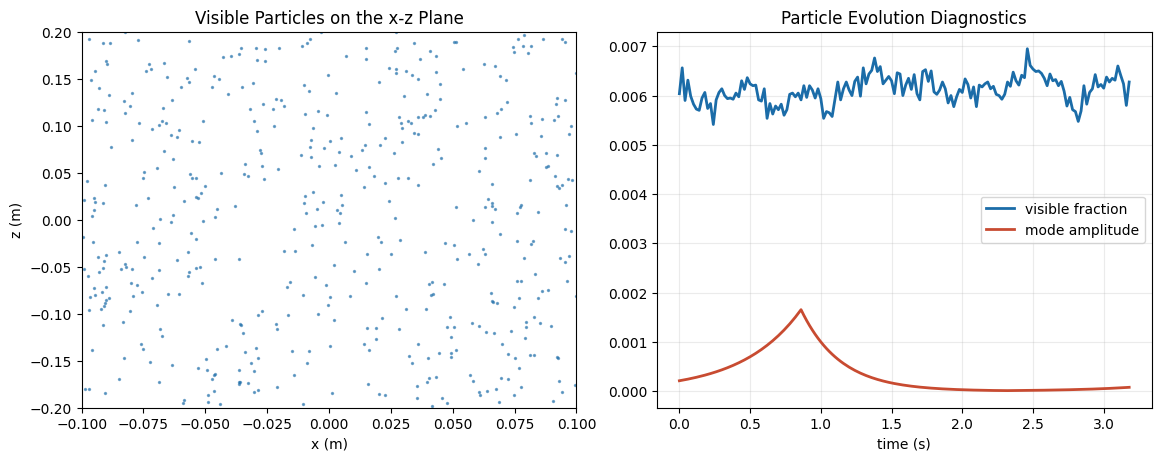

In [12]:
# Module 6B: diagnostic plots for the particle module
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)

axes[0].scatter(points[:, 0], points[:, 1], s=2.0, alpha=0.55, color="#1b6ca8")
axes[0].set_title("Visible Particles on the x-z Plane")
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("z (m)")
axes[0].set_xlim(-0.5 * cfg.Lx, 0.5 * cfg.Lx)
axes[0].set_ylim(cfg.zmin, cfg.zmax)

axes[1].plot(diag["time"], diag["visible_frac"], label="visible fraction", color="#1b6ca8", linewidth=2.0)
axes[1].plot(diag["time"], diag["amplitude"], label="mode amplitude", color="#c84b31", linewidth=2.0)
axes[1].set_title("Particle Evolution Diagnostics")
axes[1].set_xlabel("time (s)")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.show()


## Module 7: GIF Visualisation

This module turns the particle evolution history into an in-notebook GIF.

- the animation shows visible particle positions on the `x-z` plane
- each frame is annotated with time, visible fraction, and acceleration

The GIF is generated in memory and displayed directly inside the notebook.


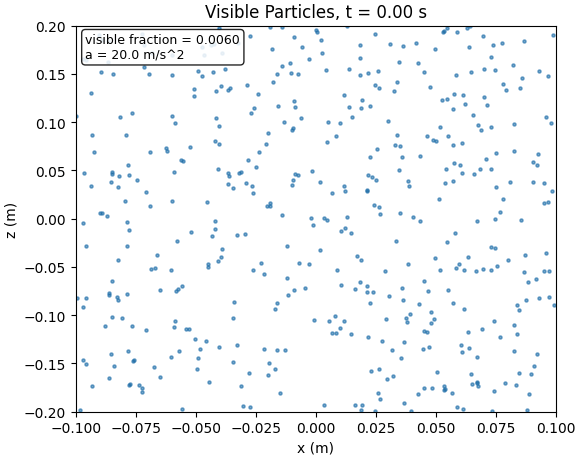

In [13]:
# Module 7: build and display an in-memory GIF
from pathlib import Path
from typing import cast
import tempfile
from matplotlib.backends.backend_agg import FigureCanvasAgg


def gif_frame_indices(frame_count: int, stride: int):
    """Sample frames at a fixed stride and always include the final frame."""
    indices = list(range(0, frame_count, max(stride, 1)))
    if indices[-1] != frame_count - 1:
        indices.append(frame_count - 1)
    return indices


def rgb_frame_from_figure(fig: plt.Figure):
    """Render a Matplotlib figure into a plain RGB array for GIF assembly."""
    fig.canvas.draw()
    canvas = cast(FigureCanvasAgg, fig.canvas)
    return np.asarray(canvas.buffer_rgba(), dtype=np.uint8)[..., :3].copy()


def gif_image_from_frames(frames: list[np.ndarray], frame_duration: float):
    """Encode a list of RGB arrays as an in-memory GIF wrapped in IPython display output."""
    with tempfile.NamedTemporaryFile(suffix=".gif", delete=False) as tmp_file:
        gif_path = Path(tmp_file.name)

    imageio.mimsave(gif_path, frames, format="GIF", duration=float(frame_duration))
    gif_bytes = gif_path.read_bytes()
    gif_path.unlink(missing_ok=True)
    return Image(data=gif_bytes, format="gif")


def build_particle_gif(
    history: dict[str, list[np.ndarray]],
    cfg: SimConfig,
    stride: int | None = None,
    frame_duration: float | None = None,
):
    """Render the particle history as a compact diagnostic GIF."""
    frames = []

    stride = cfg.gif_stride if stride is None else int(stride)
    frame_duration = cfg.gif_frame_duration if frame_duration is None else float(frame_duration)

    for idx in gif_frame_indices(len(history["time"]), stride):
        points = history["visible_points"][idx]
        time_value = history["time"][idx]
        visible_fraction = history["visible_frac"][idx]
        accel = history["acceleration"][idx]

        fig, ax = plt.subplots(figsize=(5.8, 4.6), constrained_layout=True)
        ax.scatter(points[:, 0], points[:, 1], s=5.0, alpha=0.6, color="#1b6ca8")
        ax.set_title(f"Visible Particles, t = {time_value:.2f} s")
        ax.set_xlabel("x (m)")
        ax.set_ylabel("z (m)")
        ax.set_xlim(-0.5 * cfg.Lx, 0.5 * cfg.Lx)
        ax.set_ylim(cfg.zmin, cfg.zmax)
        ax.text(
            0.02,
            0.98,
            f"visible fraction = {visible_fraction:.4f}\na = {accel:.1f} m/s^2",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
        )

        frames.append(rgb_frame_from_figure(fig))
        plt.close(fig)

    return gif_image_from_frames(frames, frame_duration)


particle_gif = build_particle_gif(
    history,
    cfg,
    stride=PARTICLE_DEBUG_OPTIONS["gif_stride"],
    frame_duration=PARTICLE_DEBUG_OPTIONS["gif_frame_duration"],
)
particle_gif